# 09 - Laboratorio Integrador: Redes Neuronales y Modelos Avanzados

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo del Laboratorio

El objetivo de este laboratorio integrado es aplicar de manera práctica y reflexiva los conocimientos adquiridos a lo largo de esta unidad temática sobre Redes Neuronales y Modelos del Estado del Arte. A través de este trabajo, ustedes consolidarán su juicio crítico al confrontar la eficiencia de distintas arquitecturas (MLP vs. CNN), implementarán inferencias flexibles mediante modelos multimodales (CLIP) y reflexionarán de forma técnico-humanista sobre los sesgos y soberanía tecnológica implícitos en el uso de IA visual.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Comparar cuantitativamente la precisión y la complejidad paramétrica de clasificadores entrenados desde cero.
2. Implementar un flujo interactivo de clasificación Zero-Shot con CLIP utilizando descripciones personalizadas en lenguaje natural.
3. Diagnosticar limitaciones semánticas y fallas sistemáticas en modelos preentrenados del estado del arte.
4. Argumentar críticamente sobre la soberanía, el sesgo cultural y la representación de datos en sistemas de visión artificial contemporáneos.

## ✦ Marco conceptual de repaso

Antes de completar las actividades, vamos a recordar brevemente qué diferencia a cada arquitectura desde el punto de vista de cómo procesan la imagen.

**Perceptrón Multicapa (MLP):**
La imagen se aplana en un vector unidimensional antes de entrar a la red. Una imagen de 28×28 px se convierte en 784 números sin ningún orden espacial. La red no "sabe" que el píxel 5 está al lado del píxel 6: los trata como números independientes.
*Analogía: como mezclar todas las piezas de un rompecabezas en una bolsa y pedir que lo armen sin ver la caja.*

**Red Convolucional (CNN):**
La imagen conserva su forma bidimensional. Los filtros se deslizan sobre regiones locales preservando la relación de vecindad entre píxeles. La red aprende a detectar bordes, texturas y formas antes de clasificar.
*Analogía: como leer el rompecabezas respetando qué piezas están adyacentes, lo que hace que los patrones sean reconocibles aunque estén ligeramente desplazados.*

Teniendo esto en mente, completen las actividades que siguen.

## Actividad 1: Contraste Empírico de Modelos (MLP vs. CNN)

### Consigna de Trabajo
Basándose en los desarrollos que completaron en los cuadernos **`02_Clasificacion_Letras_MLP.ipynb`** y **`03_Clasificacion_Letras_CNN.ipynb`**, completen la siguiente grilla analítica y respondan a las preguntas de reflexión de abajo.

### Grilla Comparativa de Resultados

| Parámetro Analítico | Perceptrón Multicapa (MLP) | Red Convolucional (CNN) |
| :--- | :--- | :--- |
| **Precisión de Prueba (Accuracy %)** | [Completar con su resultado] | [Completar con su resultado] |
| **Pérdida de Prueba (Loss)** | [Completar con su error] | [Completar con su error] |
| **Total de Parámetros de la Red** | [Completar del summary()] | [Completar del summary()] |
| **Época de Estabilización (MSE)** | [Completar aprox.] | [Completar aprox.] |

### Preguntas de Reflexión Técnica:
1. ¿Por qué la Red Convolucional (CNN) logra una precisión notablemente superior por sobre el Perceptrón Multicapa (MLP) a pesar de utilizar menos parámetros en sus etapas de análisis inicial?
2. ¿De qué manera influye el proceso de "aplanado" (`Flatten`) sobre una matriz de píxeles bidimensional en la capacidad de la red para reconocer caracteres que sufren rotación o desplazamiento?

## Actividad 2: Inferencia Flexible Interactiva con CLIP (Zero-Shot)

### Consigna de Trabajo
Utilizarán el modelo multimodal de OpenAI **CLIP** para clasificar una imagen de su elección (local o remota) mediante categorías arbitrarias redactadas en español.

In [1]:
print("✦ Cargando pipeline zero-shot de Hugging Face...")
from transformers import pipeline
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Instanciamos el pipeline de clasificación zero-shot con CLIP
clasificador_clip = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)
print("✓ CLIP listo para operar.")

✦ Cargando pipeline zero-shot de Hugging Face...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✓ CLIP listo para operar.



✓ Resultados calculados por CLIP:
-------------------------------------------------------
1. un perrito contento al aire libre → Confianza: 99.57%
2. un objeto de uso cotidiano     → Confianza: 0.41%
3. un paisaje urbano transitado   → Confianza: 0.02%
4. un gato descansando plácidamente → Confianza: 0.00%


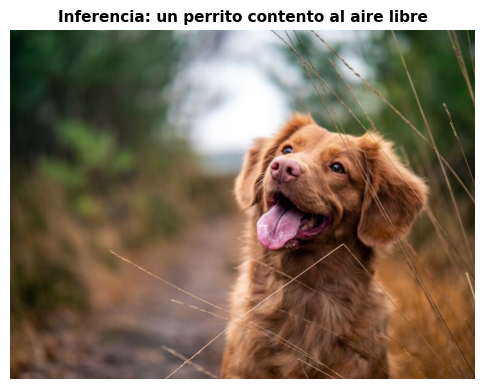

In [2]:
# =========================================================================
# PASO 1: Ingresen la dirección URL de la imagen de prueba
# =========================================================================
url_imagen = "https://images.unsplash.com/photo-1544568100-847a948585b9?w=640"

# =========================================================================
# PASO 2: Definan entre 3 y 5 categorías en lenguaje natural en español
# =========================================================================
etiquetas = [
    "un perrito contento al aire libre",
    "un gato descansando plácidamente",
    "un paisaje urbano transitado",
    "un objeto de uso cotidiano"
]

# =========================================================================
# EJECUCIÓN DE LA INFERENCIA
# =========================================================================
respuesta = requests.get(url_imagen)
imagen = Image.open(BytesIO(respuesta.content))

resultados = clasificador_clip(imagen, candidate_labels=etiquetas)

# Visualizamos las puntuaciones
print("\n✓ Resultados calculados por CLIP:")
print("-" * 55)
for i in range(len(resultados)):
    resultado = resultados[i]
    numero = i + 1
    etiqueta = resultado['label']
    confianza = resultado['score']
    porcentaje = f"{confianza:.2%}"
    print(f"{numero}. {etiqueta:30s} → Confianza: {porcentaje}")

plt.figure(figsize=(6, 6))
plt.imshow(imagen)
primera_etiqueta = resultados[0]['label']
plt.title(f"Inferencia: {primera_etiqueta}", fontsize=11, fontweight="bold")
plt.axis('off')
plt.show()

### Preguntas de Reflexión sobre CLIP:
1. Modifiquen el vector de `etiquetas` agregando descripciones sumamente detalladas y luego sumamente abstractas (ej. "felicidad", "soledad"). ¿De qué manera responde el modelo ante conceptos abstractos vs. literales?
2. Identifiquen un caso de falla o confusión semántica de CLIP. Describan qué elementos de la imagen de prueba creen que causaron la confusión del modelo multimodal.

## Actividad 3: Reflexión Crítica Técnico-Humanista (C.O.R.E.)

Respondan de manera fundamentada a los siguientes interrogantes que atraviesan los aspectos éticos, sociales y políticos del Procesamiento Digital de Imágenes contemporáneo.

### Cuestionario de Reflexión de Cierre:

1. **Soberanía Tecnológica:** Para realizar inferencias con modelos de última generación (ViT, DETR, CLIP), recurrimos a pesos preentrenados distribuidos por corporaciones globales (Google, OpenAI, Meta). ¿Qué riesgos de soberanía, dependencia técnica y sesgo de representación corremos al aplicar acríticamente estos modelos sobre problemas críticos de nuestra región (como diagnóstico médico local, seguridad social o análisis agrícola)?

2. **Sesgo Cultural y de Género en CLIP:** Teniendo en cuenta que CLIP aprendió sus asociaciones semánticas a partir de millones de textos e imágenes extraídas de Internet: ¿Qué tipo de sesgos o estereotipos sociales de género, etnia o clase creen que pueden perpetuarse al utilizar categorías libres en español en un clasificador comercial o institucional?

3. **Invisibilidad y Reducción del Sujeto:** Al implementar clasificadores como DETR, la complejidad de un sujeto o una escena es reducida a una etiqueta categórica minimalista (ej: `person`, `cat`) enmarcada por un rectángulo numérico exacto (*bounding box*). ¿De qué manera este proceso técnico de abstracción y simplificación numérica puede derivar en la deshumanización de los sujetos en sistemas de vigilancia urbana automatizada?

## Cierre de Unidad Temática

¡Felicitaciones! Completaron de manera rigurosa y reflexiva la unidad temática de Redes Neuronales. Los resultados y argumentos vertidos en este cuaderno dan cuenta de su capacidad para equilibrar la solidez técnica algorítmica con una mirada social, crítica y comprometida.